# 🃏 Mazzo vs logica — quanto conta la *scelta dell'archetipo*?

Questo notebook legge il **DB delle partite della competizione** (`ptcg_data/matches.db`,
costruito da [`competiotion_scraper.py`](competiotion_scraper.py) dai replay Kaggle) e risponde
a una domanda precisa:

> **Quanto è importante il mazzo che scegli, rispetto al saperlo giocare bene?**

Per farlo:

1. **Archetipi dai mazzi** — ogni decklist da 60 carte viene etichettata con un *archetipo*
   (le sue Pokémon chiave), così due team che portano lo stesso mazzo finiscono nello stesso gruppo.
2. **Archetipi più giocati** — quota del campo (*meta share*) e quanti team pilotano ciascuno.
3. **Efficacia assoluta** — winrate complessivo di ogni archetipo, mediato su tutti i suoi piloti.
4. **Matrice degli scontri** — winrate archetipo-vs-archetipo (chi batte chi).
5. **Mazzo vs logica** — scomposizione della varianza dei risultati in *quanto spiega l'archetipo*
   (la scelta del mazzo) vs *quanto spiega il pilota a parità di archetipo* (la logica di gioco).

> Serve `meta_utils` e `competiotion_scraper` (già nella cartella). Se non c'è un DB reale il
> notebook ricade sul DB **dimostrativo** (dati sintetici) così resta comunque eseguibile —
> per i numeri veri popola il DB con lo scraper (istruzioni in fondo).


In [2]:
import sys, sqlite3, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import meta_utils as mu
import competiotion_scraper as scr

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "figure.autolayout": True})
PAL = plt.get_cmap("tab10").colors

def save(fig, name):
    fig.savefig(mu.FIG_DIR / f"04_{name}.png", bbox_inches="tight", dpi=130)

# --- card pool robusto: il CSV puo' stare in doc/ oppure in view_replays/card_data ----
def _find_card_csv():
    cands = [mu.EN_CARD_CSV,
             mu.ROOT / "view_replays" / "card_data" / "EN_Card_Data.csv",
             mu.ROOT / "doc" / "pokemon-tcg-ai-battle" / "EN_Card_Data.csv"]
    for p in cands:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError("EN_Card_Data.csv non trovato (cercato in doc/ e view_replays/card_data/)")

CARD_CSV = _find_card_csv()
pool = mu.cards_unique(mu.load_cards(CARD_CSV)).set_index("Card ID")
CARD_NAME = pool["Card Name"].to_dict()
print("Card pool:", len(pool), "carte da", CARD_CSV.relative_to(mu.ROOT))

# Lo scraper scrive i nomi carta leggendo un CSV che qui potrebbe non esistere: gli passo
# la mappa gia' pronta cosi' scrape()/save_episode lanciati da qui non vanno in errore.
scr._CARD_NAMES = CARD_NAME

# --- DB dimostrativo autonomo (non usa il path hard-coded di make_demo_db) --------------
def build_demo_db(path, n_matches=140, seed=7):
    """DB sintetico con la struttura reale: 8 team su 4 archetipi (2 piloti ciascuno),
    con abilita' diverse a parita' di mazzo, cosi' l'analisi mazzo-vs-logica ha di che lavorare."""
    rng = np.random.RandomState(seed)
    if Path(path).exists():
        Path(path).unlink()
    # 4 archetipi = 2 Pokemon chiave (preferendo ex/Mega) + riempimento
    poke = pool[pool["is_pokemon"]].copy()
    key_pool = poke.sort_values(["is_mega", "is_ex", "hp_num"], ascending=False).head(40).index.tolist()
    fill_pool = pool.index.tolist()
    rng.shuffle(key_pool)
    archs = {}
    for i in range(4):
        keys = key_pool[2 * i:2 * i + 2]
        archs[f"arch{i}"] = keys + list(rng.choice(fill_pool, 10, replace=False))
    # 8 team: 2 per archetipo, con offset di abilita'
    teams = {f"team{t}": (f"arch{t % 4}", 0.62 - 0.09 * (t // 4)) for t in range(8)}
    conn = scr.get_db(path)
    names = list(teams)
    for m in range(n_matches):
        a0, a1 = rng.choice(names, 2, replace=False)
        s0, s1 = teams[a0][1], teams[a1][1]
        w = 0 if rng.rand() < s0 / (s0 + s1) else 1
        parsed = {"episode_id": f"demo-{m:04d}", "agents": [a0, a1],
                  "rewards": [1.0, -1.0] if w == 0 else [-1.0, 1.0], "winner": w,
                  "n_steps": int(rng.randint(30, 120)), "n_plays": 0,
                  "deck_player0": [], "deck_player1": [], "play_sequence": []}
        for pidx, ag in ((0, a0), (1, a1)):
            cards = archs[teams[ag][0]]
            parsed[f"deck_player{pidx}"] = list(rng.choice(cards, 60))
        scr.save_episode(conn, parsed)
    conn.close()
    return path

def pick_db():
    real, demo = scr.DB_PATH, scr.DEMO_DB_PATH
    if real.exists():
        n = sqlite3.connect(real).execute("select count(*) from matches").fetchone()[0]
        if n > 0:
            return real, False
    print("Nessun DB reale: genero un DB dimostrativo (dati sintetici)...")
    build_demo_db(demo)
    return demo, True

DB_PATH, IS_DEMO = pick_db()
conn = sqlite3.connect(DB_PATH)
matches = pd.read_sql("select * from matches", conn)
decks   = pd.read_sql("select * from match_decks", conn)

banner = ("DATI DIMOSTRATIVI (sintetici) - popola il DB con lo scraper per i numeri reali."
          if IS_DEMO else "Dati reali dal DB delle partite.")
print("="*88); print(banner)
print("DB:", DB_PATH.name, "| partite:", len(matches), "| mazzi:", decks["episode_id"].nunique())
print("="*88)

Card pool: 1267 carte da doc\pokemon-tcg-ai-battle\EN_Card_Data.csv
Dati reali dal DB delle partite.
DB: matches.db | partite: 8624 | mazzi: 8624


## 0. Dagli mazzi agli archetipi

Ogni riga di `match_decks` è una carta di un mazzo (60 carte per giocatore). Etichettiamo il mazzo
con le sue **Pokémon chiave** — diamo priorità a Mega ed *ex*, poi agli HP più alti — così due
decklist con lo stesso nucleo ricevono lo stesso archetipo. È un'euristica volutamente semplice ma
stabile: nella competizione ogni submission porta un mazzo fisso, quindi lo stesso team ricade
sempre nello stesso archetipo.

In [3]:
TOP_KEY_POKEMON = 2   # quante Pokemon chiave nel nome dell'archetipo

def deck_signature(card_copies: dict) -> str:
    """Etichetta un mazzo dalle sue Pokemon piu' rilevanti (Mega/ex/HP)."""
    poke = []
    other = []
    for cid, cp in card_copies.items():
        if cid not in pool.index:
            continue
        r = pool.loc[cid]
        entry = (bool(r["is_mega"]), bool(r["is_ex"]), float(r["hp_num"] or 0), int(cp),
                 str(r["Card Name"]))
        (poke if bool(r["is_pokemon"]) else other).append(entry)
    src = poke or other
    if not src:
        return "(non classificato)"
    src.sort(reverse=True)   # Mega > ex > HP > copie
    names = []
    for *_, nm in src:
        if nm not in names:
            names.append(nm)
        if len(names) >= TOP_KEY_POKEMON:
            break
    return " + ".join(names)

# firma per ogni (episodio, giocatore)
sig_map = {}
for (ep, pidx), grp in decks.groupby(["episode_id", "player_idx"]):
    sig_map[(ep, int(pidx))] = deck_signature(dict(zip(grp["card_id"], grp["copies"])))

# tabella "lunga": una riga per giocatore-partita
recs = []
for _, m in matches.iterrows():
    ep, w = m["episode_id"], m["winner_idx"]
    ag = [m["agent0"], m["agent1"]]
    ar = [sig_map.get((ep, 0), "(non classificato)"), sig_map.get((ep, 1), "(non classificato)")]
    for s in (0, 1):
        recs.append({
            "episode_id": ep, "side": s, "agent": ag[s], "archetype": ar[s],
            "opp_agent": ag[1 - s], "opp_archetype": ar[1 - s],
            "won": np.nan if pd.isna(w) else int(w == s),
        })
games = pd.DataFrame(recs)
decided = games.dropna(subset=["won"]).copy()
decided["won"] = decided["won"].astype(int)

print(f"Archetipi distinti: {games['archetype'].nunique()} | "
      f"partite decise: {len(decided)//2} | pilotati da {games['agent'].nunique()} team")
games.head(6)

Archetipi distinti: 154 | partite decise: 8614 | pilotati da 1346 team


,episode_id,side,agent,archetype,opp_agent,opp_archetype,won
0,88062288,0,LiamK,Mega Kangaskhan ex + Crustle,Azat Akhtyamov,Fezandipiti ex + Alakazam,0.0
1,88062288,1,Azat Akhtyamov,Fezandipiti ex + Alakazam,LiamK,Mega Kangaskhan ex + Crustle,1.0
2,88061084,0,Brahim,Mega Kangaskhan ex + Crustle,Azat Akhtyamov,Fezandipiti ex + Alakazam,0.0
3,88061084,1,Azat Akhtyamov,Fezandipiti ex + Alakazam,Brahim,Mega Kangaskhan ex + Crustle,1.0
4,88060456,0,me and the lads,Marnie's Grimmsnarl ex + Munkidori,Azat Akhtyamov,Fezandipiti ex + Alakazam,1.0
5,88060456,1,Azat Akhtyamov,Fezandipiti ex + Alakazam,me and the lads,Marnie's Grimmsnarl ex + Munkidori,0.0


## 1. Archetipi più giocati (quota del campo)

Quante partite gioca ciascun archetipo e da quanti team diversi è pilotato. Un archetipo molto
diffuso *e* portato da tanti team è un pilastro della meta.

,archetype,partite,piloti,quota_%
0,Marnie's Grimmsnarl ex + Munkidori,6934,200,40.2
1,Fezandipiti ex + Alakazam,3948,248,22.9
2,Team Rocket's Mewtwo ex + Team Rocket's Spidops,1324,54,7.7
3,Cynthia's Garchomp ex + Cynthia's Roserade,1133,58,6.6
4,Mega Kangaskhan ex + Crustle,864,75,5.0
5,Dragapult ex + Fezandipiti ex,322,31,1.9
6,Mega Kangaskhan ex + Cornerstone Mask Ogerpon ex,200,5,1.2
7,Mega Lucario ex + Solrock,192,18,1.1
8,Mega Kangaskhan ex + Raging Bolt ex,183,2,1.1
9,Archaludon ex + Cinderace,159,100,0.9


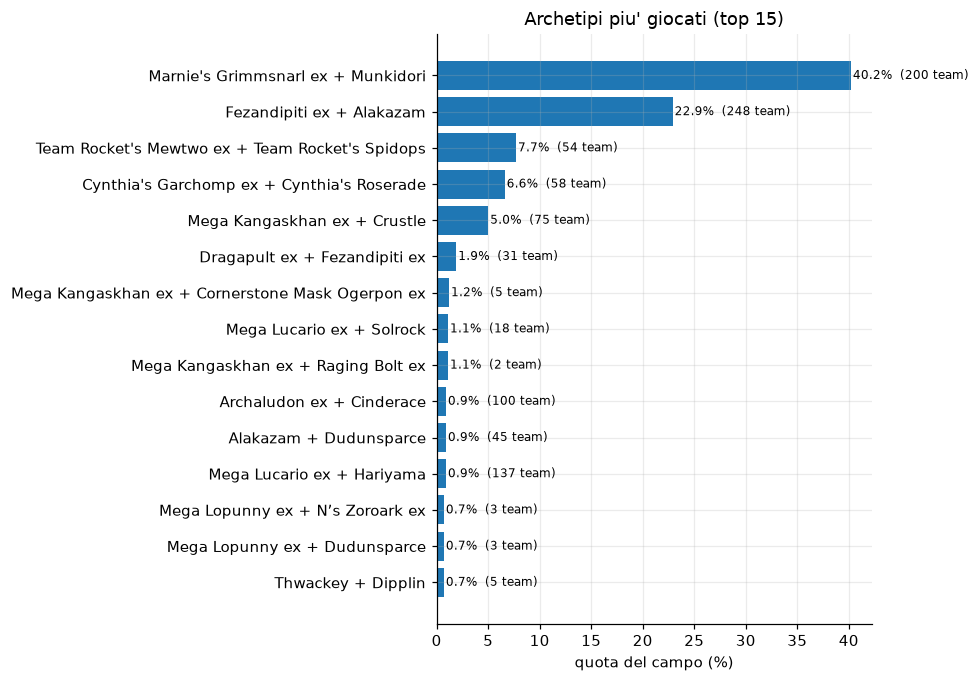

In [4]:
pop = (games.groupby("archetype")
       .agg(partite=("episode_id", "size"),
            piloti=("agent", "nunique"))
       .reset_index())
pop["quota_%"] = (100 * pop["partite"] / pop["partite"].sum()).round(1)
pop = pop.sort_values("partite", ascending=False).reset_index(drop=True)
display(pop.head(20))

TOPN = min(15, len(pop))
top = pop.head(TOPN).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(3, .42 * TOPN)))
ax.barh(top["archetype"], top["quota_%"], color=PAL[0])
for y, (q, k) in enumerate(zip(top["quota_%"], top["piloti"])):
    ax.text(q + .2, y, f"{q:.1f}%  ({k} team)", va="center", fontsize=8)
ax.set_xlabel("quota del campo (%)"); ax.set_title(f"Archetipi piu' giocati (top {TOPN})")
save(fig, "popolarita"); plt.show()
pop.to_csv(mu.DATA_DIR / "04_archetipi_popolarita.csv", index=False)

## 2. Efficacia assoluta di ogni archetipo

Winrate complessivo dell'archetipo, **mediato su tutti i suoi piloti**. È la risposta a *"se scelgo
questo mazzo, in media quanto vinco?"* — indipendentemente da chi lo guida. Mostriamo solo gli
archetipi con abbastanza partite perché il winrate sia informativo.

,archetype,partite,piloti,winrate_%
0,Thwackey + Dipplin,115,5,62.6
1,Mega Kangaskhan ex + Raging Bolt ex,183,2,61.7
2,Hydrapple ex + Teal Mask Ogerpon ex,43,5,60.5
3,Cynthia's Garchomp ex + Cynthia's Roserade,1133,58,57.1
4,Cornerstone Mask Ogerpon ex + Team Rocket's Ar...,109,3,56.9
5,N’s Zoroark ex + N’s Reshiram,110,2,56.4
6,Dragapult ex + Fezandipiti ex,321,31,56.1
7,Team Rocket's Mewtwo ex + Team Rocket's Spidops,1322,54,55.1
8,Mega Kangaskhan ex + Cornerstone Mask Ogerpon ex,200,5,54.5
9,Marnie's Grimmsnarl ex + Munkidori,6926,200,53.5


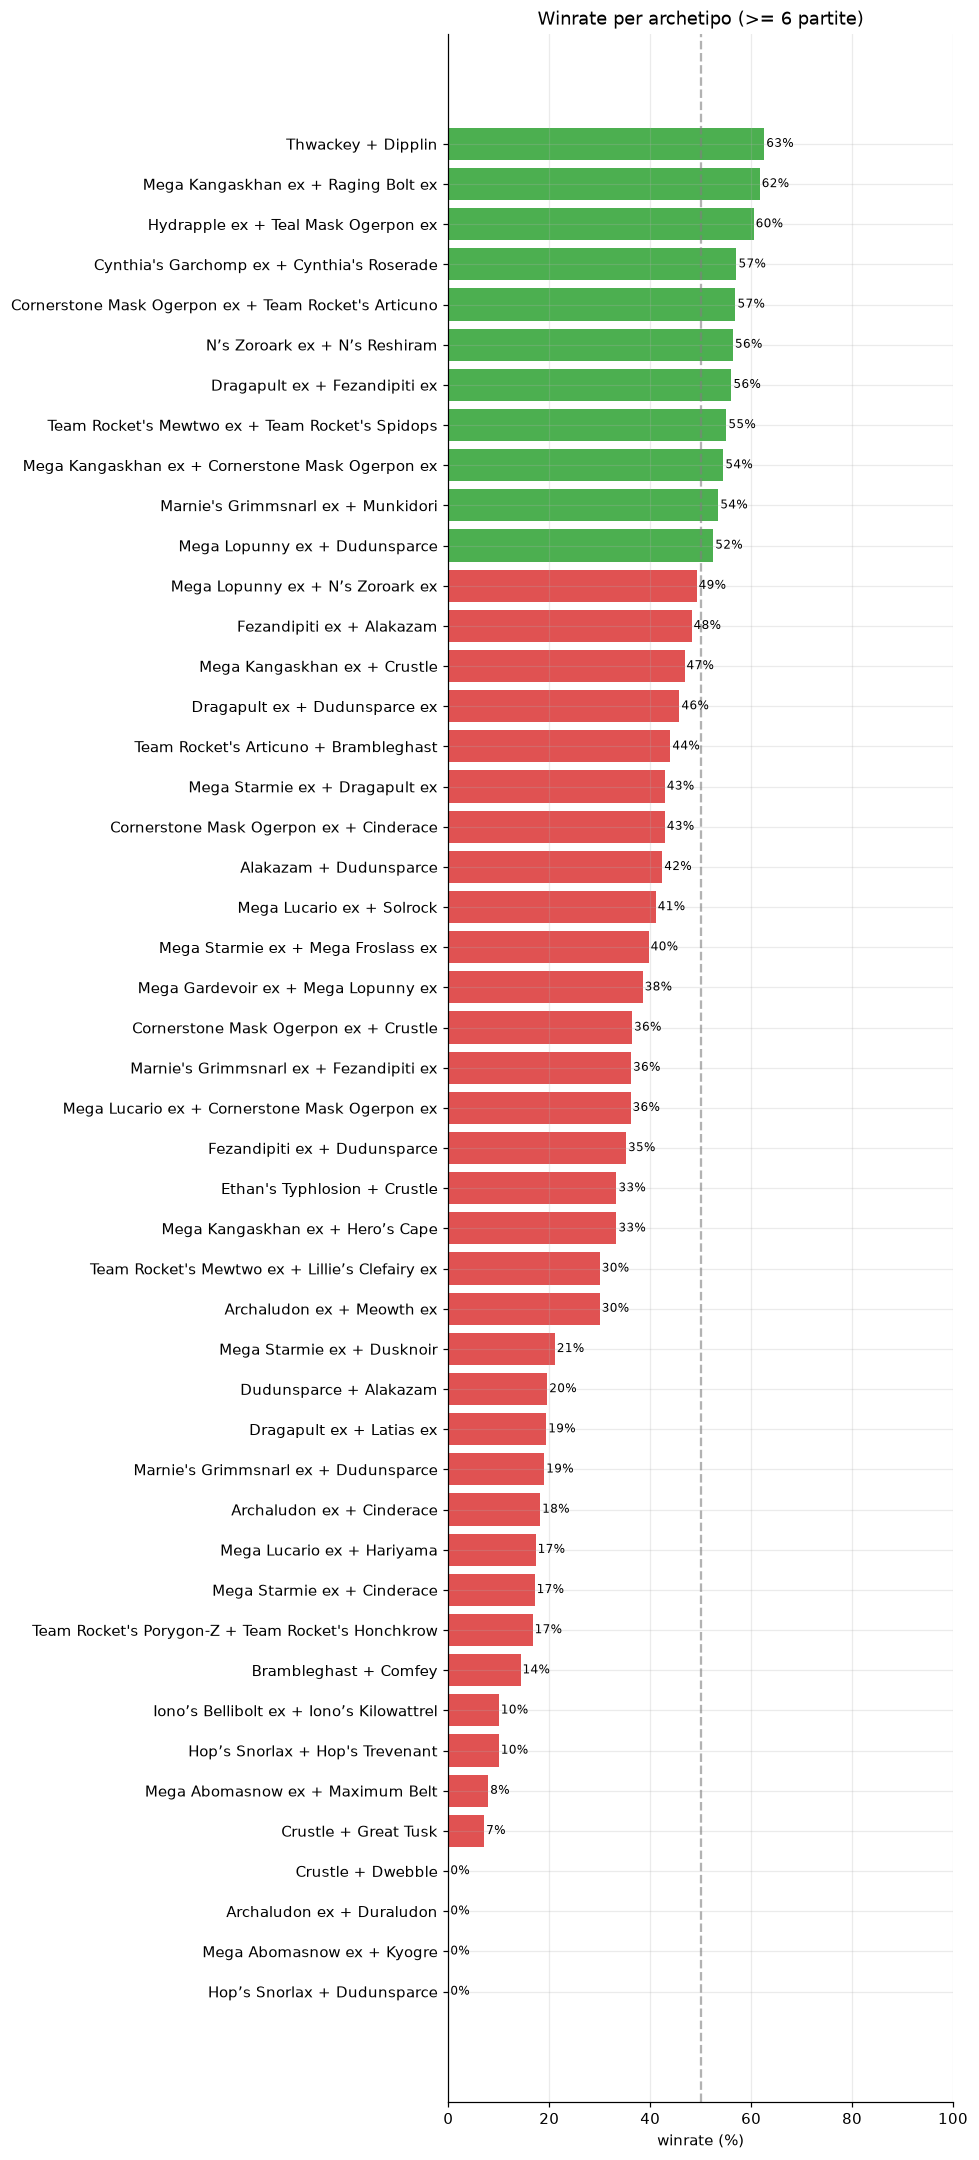

In [5]:
MIN_GAMES = 6 if not IS_DEMO else 2

wr = (decided.groupby("archetype")
      .agg(partite=("won", "size"), winrate=("won", "mean"), piloti=("agent", "nunique"))
      .reset_index())
wr = wr[wr["partite"] >= MIN_GAMES].sort_values("winrate", ascending=False).reset_index(drop=True)
wr["winrate_%"] = (100 * wr["winrate"]).round(1)
display(wr[["archetype", "partite", "piloti", "winrate_%"]])

if len(wr):
    t = wr.iloc[::-1]
    colors = ["#4caf50" if v >= 50 else "#e05252" for v in t["winrate_%"]]
    fig, ax = plt.subplots(figsize=(9, max(3, .42 * len(t))))
    ax.barh(t["archetype"], t["winrate_%"], color=colors)
    ax.axvline(50, ls="--", color="grey", alpha=.6)
    for y, v in enumerate(t["winrate_%"]):
        ax.text(v + .4, y, f"{v:.0f}%", va="center", fontsize=8)
    ax.set_xlim(0, 100); ax.set_xlabel("winrate (%)")
    ax.set_title(f"Winrate per archetipo (>= {MIN_GAMES} partite)")
    save(fig, "winrate_archetipi"); plt.show()
else:
    print(f"Nessun archetipo con >= {MIN_GAMES} partite: servono piu' dati (lancia lo scraper).")

## 3. Matrice degli scontri (archetipo vs archetipo)

Per ogni coppia, la **% di vittorie della riga contro la colonna**. Verde = la riga domina,
rosso = la riga soffre. Rivela i rapporti di forza (*chi batte chi*) e quanto la meta è a
*morra cinese* — se ogni mazzo ne batte alcuni e ne perde altri, la **scelta** conta molto.

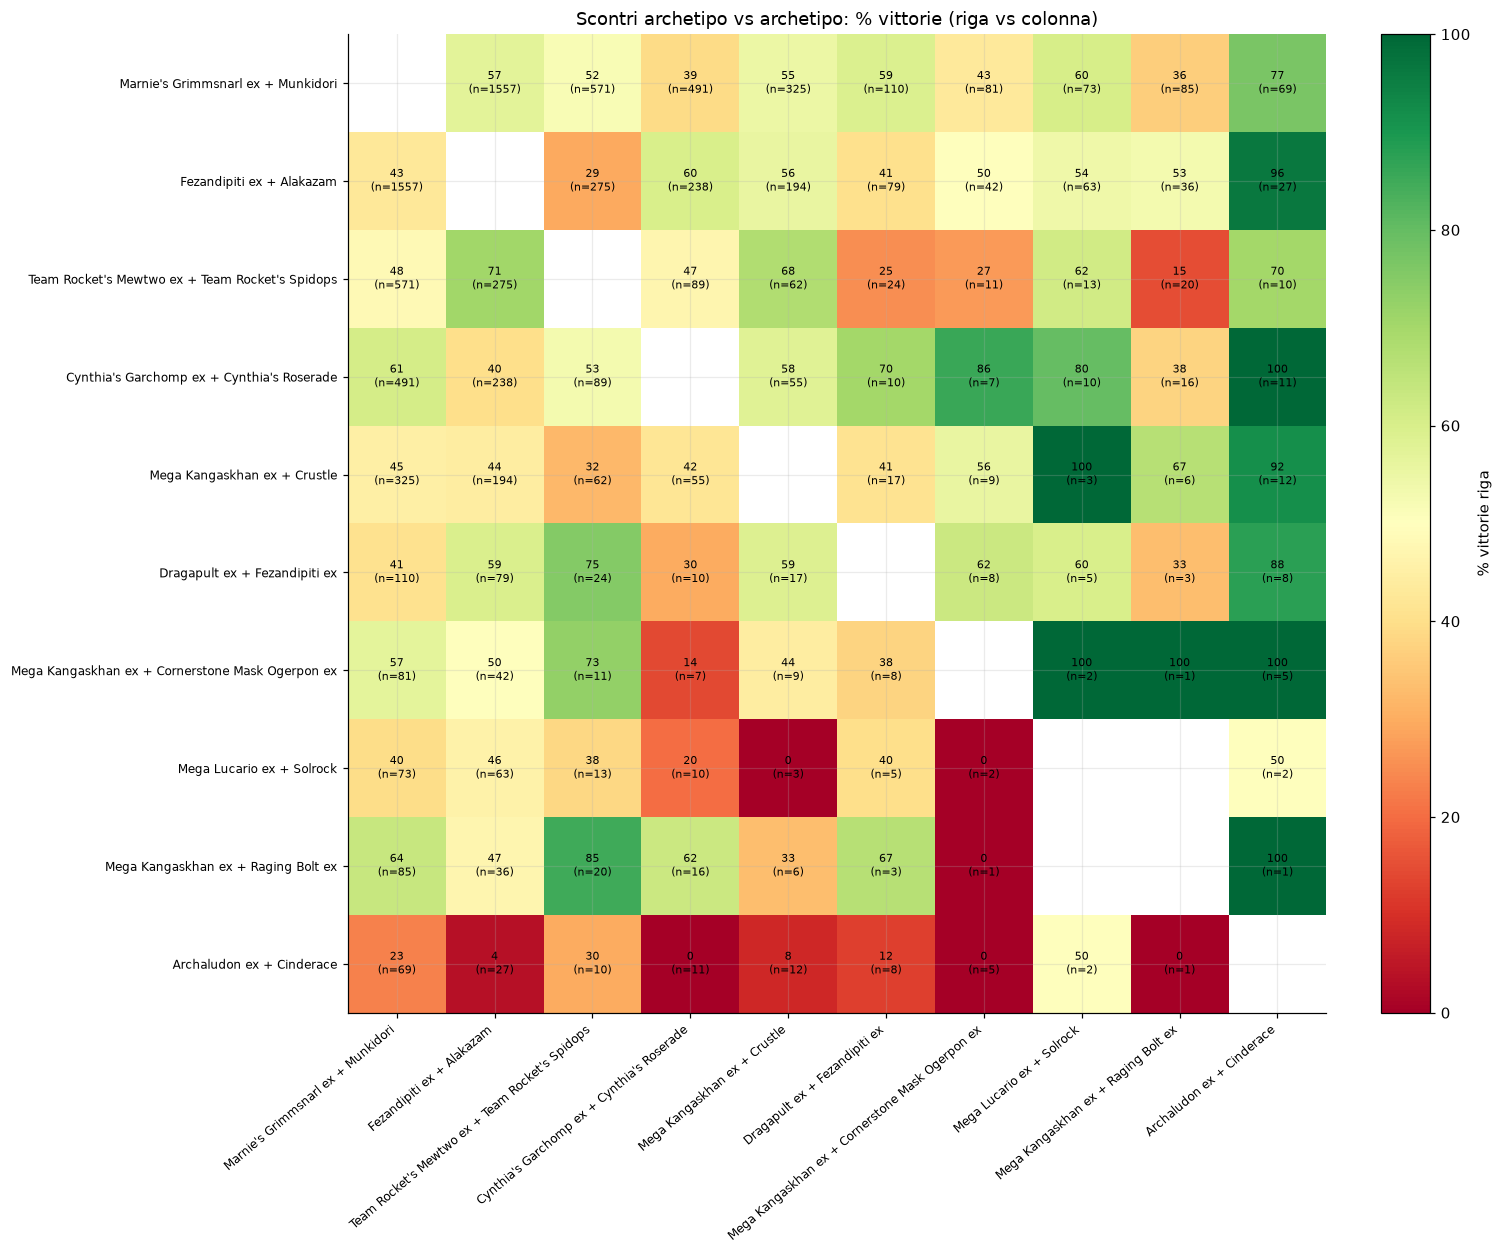

In [6]:
MATCHUP_TOP = min(10, wr["archetype"].nunique() if len(wr) else 0)
keep = (decided.groupby("archetype").size().sort_values(ascending=False)
        .head(MATCHUP_TOP).index.tolist())
sub = decided[decided["archetype"].isin(keep) & decided["opp_archetype"].isin(keep)]

mat = pd.DataFrame(np.nan, index=keep, columns=keep)
cnt = pd.DataFrame(0, index=keep, columns=keep)
for (a, b), g in sub.groupby(["archetype", "opp_archetype"]):
    if a == b:
        continue
    mat.loc[a, b] = 100 * g["won"].mean()
    cnt.loc[a, b] = len(g)

if len(keep) >= 2:
    fig, ax = plt.subplots(figsize=(1.05 * len(keep) + 3, 0.95 * len(keep) + 2))
    im = ax.imshow(mat.values.astype(float), cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_xticks(range(len(keep))); ax.set_xticklabels(keep, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(keep))); ax.set_yticklabels(keep, fontsize=8)
    for i in range(len(keep)):
        for j in range(len(keep)):
            v = mat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}\n(n={cnt.values[i, j]})", ha="center", va="center", fontsize=7)
    ax.set_title("Scontri archetipo vs archetipo: % vittorie (riga vs colonna)")
    plt.colorbar(im, ax=ax, fraction=.046, label="% vittorie riga")
    save(fig, "matchup_matrix"); plt.show()
else:
    print("Troppi pochi archetipi con partite sufficienti per la matrice.")

## 4. La domanda centrale: **mazzo vs logica di gioco**

Ogni partita decisa è spiegabile da tre fonti:

- **l'archetipo** (la *scelta del mazzo*),
- **il pilota, a parità di archetipo** (la *logica di gioco*: stesso mazzo, team diversi),
- **il caso** (varianza partita-a-partita: mulligan, pescate, ecc.).

Scomponiamo la varianza dei risultati (somma dei quadrati, stile ANOVA) in queste tre quote.

- Se la fetta **archetipo** è molto più grande di quella **pilota** → conta di più *cosa* giochi:
  la scelta del mazzo domina.
- Se la fetta **pilota (a parità di archetipo)** è grande → a parità di mazzo i team ottengono
  risultati molto diversi: conta di più *come* lo giochi (la logica).

In più isoliamo gli **specchi** (stesso archetipo su entrambi i lati): lì il mazzo è identico,
quindi l'esito dipende **solo** dalla logica di gioco.

> Nota: su un esito binario di *singola partita* la fetta **caso** è per forza enorme (rumore di
> Bernoulli) e si media via su tante partite — non significa che il gioco sia "per il 97% fortuna".
> Il confronto che conta è il **rapporto** tra le due fette spiegate (mazzo vs logica), riportato
> nel verdetto qui sotto.

Scomposizione della varianza dei risultati:
    3.6%  <- Archetipo (scelta del mazzo)
    8.7%  <- Pilota a parita' di archetipo (logica)
   87.6%  <- Caso (varianza partita-a-partita)

>> La LOGICA domina: a parita' di mazzo i piloti fanno la differenza (~71% del segnale).


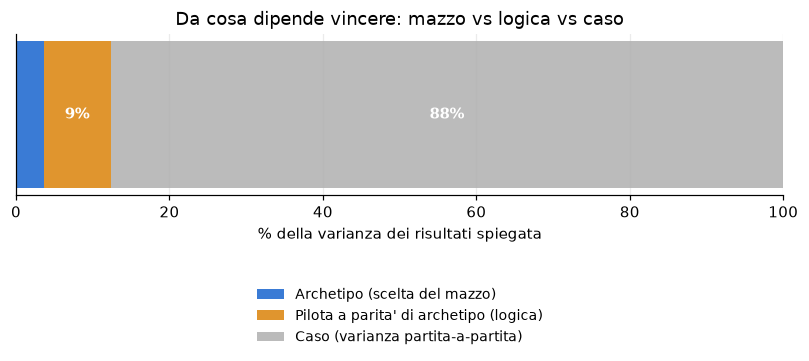


Partite 'specchio' (stesso archetipo da entrambi i lati): 1999
  In questi match il mazzo e' identico: chi vince lo decide SOLO la logica di gioco.
  Winrate dei piloti negli specchi (stesso mazzo, quindi pura abilita'):


partite  \
archetype                                       agent                          
Fezandipiti ex + Alakazam                       Jeffrey Pike               3   
                                                ZHYW                       2   
                                                Orion                      2   
                                                tamakiken_OB               2   
Team Rocket's Mewtwo ex + Team Rocket's Spidops LiamK                      9   
Cynthia's Garchomp ex + Cynthia's Roserade      junlee789                  7   
Marnie's Grimmsnarl ex + Munkidori              Azat Akhtyamov            12   
Mega Kangaskhan ex + Crustle                    koala_bear “もりたにあん”        6   
Fezandipiti ex + Alakazam                       Majkel1337                39   
Marnie's Grimmsnarl ex + Munkidori              cm391                      4   
                                                MIRAI LAB                  4   
                                                lolzpo + emonga            4   

                                                                     winrate_pct  
archetype                                       agent                             
Fezandipiti ex + Alakazam                       Jeffrey Pike               100.0  
                                                ZHYW                       100.0  
                                                Orion                      100.0  
                                                tamakiken_OB               100.0  
Team Rocket's Mewtwo ex + Team Rocket's Spidops LiamK                       89.0  
Cynthia's Garchomp ex + Cynthia's Roserade      junlee789                   86.0  
Marnie's Grimmsnarl ex + Munkidori              Azat Akhtyamov              83.0  
Mega Kangaskhan ex + Crustle                    koala_bear “もりたにあん”         83.0  
Fezandipiti ex + Alakazam                       Majkel1337                  77.0  
Marnie's Grimmsnarl ex + Munkidori              cm391                       75.0  
                                                MIRAI LAB                   75.0  
                                                lolzpo + emonga             75.0

In [7]:
d = decided
grand = d["won"].mean()
ss_total = float(((d["won"] - grand) ** 2).sum())

# SS spiegata dall'archetipo
arch_mean = d.groupby("archetype")["won"].transform("mean")
ss_arch = float(((arch_mean - grand) ** 2).sum())

# SS spiegata dal pilota A PARITA' di archetipo (scarto pilota-vs-medietipo)
ap_mean = d.groupby(["archetype", "agent"])["won"].transform("mean")
ss_pilot = float(((ap_mean - arch_mean) ** 2).sum())

ss_resid = max(ss_total - ss_arch - ss_pilot, 0.0)
parts = {"Archetipo (scelta del mazzo)": ss_arch,
         "Pilota a parita' di archetipo (logica)": ss_pilot,
         "Caso (varianza partita-a-partita)": ss_resid}
shares = {k: (v / ss_total if ss_total else 0) for k, v in parts.items()}

print("Scomposizione della varianza dei risultati:")
for k, v in shares.items():
    print(f"  {v*100:5.1f}%  <- {k}")

eta_arch, eta_pilot = shares["Archetipo (scelta del mazzo)"], shares["Pilota a parita' di archetipo (logica)"]
if eta_arch + eta_pilot > 0:
    rel = eta_arch / (eta_arch + eta_pilot)
    if rel > 0.6:
        verdict = f"Il MAZZO domina: a parita' di logica, la scelta dell'archetipo pesa ~{rel*100:.0f}% del segnale."
    elif rel < 0.4:
        verdict = f"La LOGICA domina: a parita' di mazzo i piloti fanno la differenza (~{(1-rel)*100:.0f}% del segnale)."
    else:
        verdict = f"Contano ENTRAMBI in modo simile (mazzo ~{rel*100:.0f}% / logica ~{(1-rel)*100:.0f}%)."
else:
    verdict = "Dati insufficienti per un verdetto."
print("\n>>", verdict)

fig, ax = plt.subplots(figsize=(9, 1.9))
left = 0
cols = ["#3a7bd5", "#e0952e", "#bbbbbb"]
for (k, v), c in zip(shares.items(), cols):
    ax.barh(0, v * 100, left=left, color=c, label=k)
    if v > 0.04:
        ax.text(left + v * 50, 0, f"{v*100:.0f}%", ha="center", va="center", color="white", fontsize=10, weight="bold")
    left += v * 100
ax.set_xlim(0, 100); ax.set_yticks([]); ax.set_xlabel("% della varianza dei risultati spiegata")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.5), ncol=1, frameon=False, fontsize=9)
ax.set_title("Da cosa dipende vincere: mazzo vs logica vs caso")
save(fig, "mazzo_vs_logica"); plt.show()

# --- controprova con gli specchi: stesso archetipo su entrambi i lati -------------------
mirror = d[d["archetype"] == d["opp_archetype"]]
n_mirror = len(mirror) // 2
print(f"\nPartite 'specchio' (stesso archetipo da entrambi i lati): {n_mirror}")
print("  In questi match il mazzo e' identico: chi vince lo decide SOLO la logica di gioco.")
if n_mirror:
    mp = (mirror.groupby(["archetype", "agent"])["won"].agg(["mean", "size"])
          .query("size >= 2").sort_values("mean", ascending=False))
    if len(mp):
        print("  Winrate dei piloti negli specchi (stesso mazzo, quindi pura abilita'):")
        display((mp.assign(winrate_pct=(mp["mean"]*100).round(0)).rename(columns={"size": "partite"})
                 [["partite", "winrate_pct"]]).head(12))

## 5. Quanto può fare un buon pilota su un dato mazzo

Per gli archetipi con almeno due piloti: sull'asse X il winrate **medio** dell'archetipo, sull'asse Y
il winrate del suo **miglior** pilota. Più i punti stanno sopra la diagonale, più un pilota bravo
"tira su" lo stesso mazzo → la logica di gioco conta.

,archetype,piloti,wr_medio,wr_migliore,wr_peggiore,divario_%
9,Marnie's Grimmsnarl ex + Munkidori,117,43.0,86.0,0.0,86.0
6,Fezandipiti ex + Alakazam,97,37.0,83.0,0.0,83.0
11,Mega Kangaskhan ex + Crustle,29,37.0,75.0,0.0,75.0
4,Dragapult ex + Dudunsparce ex,3,35.0,73.0,0.0,73.0
1,Archaludon ex + Cinderace,8,24.0,60.0,0.0,60.0
0,Alakazam + Dudunsparce,4,39.0,58.0,0.0,58.0
14,Mega Lucario ex + Solrock,10,27.0,58.0,0.0,58.0
16,Team Rocket's Mewtwo ex + Team Rocket's Spidops,22,47.0,65.0,12.0,53.0
5,Dragapult ex + Fezandipiti ex,4,42.0,66.0,17.0,49.0
3,Cynthia's Garchomp ex + Cynthia's Roserade,17,55.0,80.0,31.0,49.0


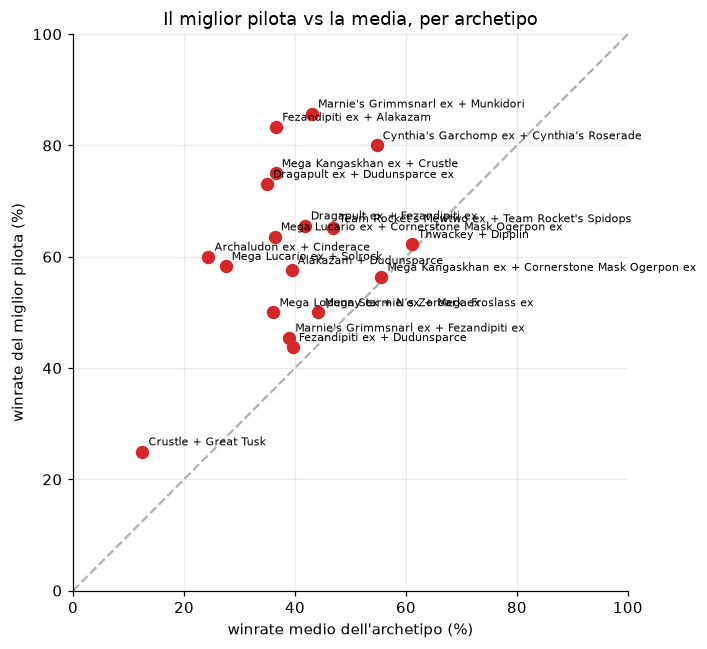

In media il miglior pilota di un archetipo fa +22 punti di winrate sulla media del mazzo.


In [8]:
MIN_PILOT_GAMES = 4 if not IS_DEMO else 1
ap = (decided.groupby(["archetype", "agent"])["won"].agg(g="size", wr="mean").reset_index())
ap = ap[ap["g"] >= MIN_PILOT_GAMES]
rows = []
for arch, grp in ap.groupby("archetype"):
    if grp["agent"].nunique() < 2:
        continue
    rows.append({"archetype": arch, "piloti": grp["agent"].nunique(),
                 "wr_medio": grp["wr"].mean(), "wr_migliore": grp["wr"].max(),
                 "wr_peggiore": grp["wr"].min()})
lift = pd.DataFrame(rows)

if len(lift):
    lift["divario_%"] = ((lift["wr_migliore"] - lift["wr_peggiore"]) * 100).round(0)
    display(lift.assign(wr_medio=(lift.wr_medio*100).round(0),
                        wr_migliore=(lift.wr_migliore*100).round(0),
                        wr_peggiore=(lift.wr_peggiore*100).round(0))
            .sort_values("divario_%", ascending=False))
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot([0, 100], [0, 100], ls="--", color="grey", alpha=.6)
    ax.scatter(lift["wr_medio"]*100, lift["wr_migliore"]*100, s=60, color=PAL[3], zorder=3)
    for _, r in lift.iterrows():
        ax.annotate(r["archetype"], (r["wr_medio"]*100, r["wr_migliore"]*100),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("winrate medio dell'archetipo (%)")
    ax.set_ylabel("winrate del miglior pilota (%)")
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_title("Il miglior pilota vs la media, per archetipo")
    save(fig, "lift_pilota"); plt.show()
    gap = (lift["wr_migliore"] - lift["wr_medio"]).mean() * 100
    print(f"In media il miglior pilota di un archetipo fa +{gap:.0f} punti di winrate sulla media del mazzo.")
else:
    print(f"Nessun archetipo con >= 2 piloti (>= {MIN_PILOT_GAMES} partite ciascuno): servono piu' dati.")

---
### Come popolare il DB con dati reali (nessuna credenziale)

Lo scraper usa gli endpoint pubblici del sito Kaggle (leaderboard → episodi → replay), quindi
**non serve** `kaggle.json`:

```bash
python competiotion_scraper.py check                    # verifica accesso all'API pubblica
python competiotion_scraper.py scrape --teams 25 --episodes 12   # popola ptcg_data/matches.db
```

Poi riesegui questo notebook: rileverà il DB reale e i banner "DIMOSTRATIVI" spariranno.

**Cautele di lettura.** Con pochi episodi per team i winrate hanno larghe barre d'errore, e
l'euristica di archetipo (Pokémon chiave del mazzo) può accorpare o separare qualche lista al
margine. La scomposizione mazzo-vs-logica è indicativa: con più partite per pilota diventa
progressivamente più affidabile.
